In [1]:
# RGTransformer 训练器
# 说明：每个阶段都可以独立运行，不依赖其他阶段的执行
%reload_ext autoreload
%autoreload 2

# %% 0. 导入必要的库
import sys
import os

sys.path.append('/home/morisi/Workspace/3D-Ocean')

from src.trainer.base import BaseTrainer, BasePrediction
from src.models.SST.RGTransformer import RGTransformer
from src.config.area import Area
from src.config.params import PROJECT_PATH
from src.dataset.OISST import OISSTMonthlyDataset

print("✅ 库导入完成")
print(f"项目根目录: {PROJECT_PATH}")


/home/morisi/Workspace/3D-Ocean/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/morisi/Workspace/3D-Ocean/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happen

✅ 库导入完成
项目根目录: /home/morisi/Workspace/3D-Ocean


In [2]:
# %% 全局配置（所有阶段共享）
# 这个cell定义了所有阶段共享的配置参数，每次运行任何阶段前都需要先运行这个cell

area = Area('Global', lon=[-180, 180], lat=[-80, 80], description='全球区域')

# 基础配置参数
resolution = 1
seq_len = 2
offset = 0
use_checkpoint = True

# 计算空间尺寸
width = int(area.width / resolution)
height = int(area.height / resolution)

# 数据集参数
dataset_params = {
    "seq_len": seq_len,
    "offset": offset,
    "resolution": resolution,
}

# 训练器参数（基础配置）
trainer_epochs = 100 # 先定义训练轮数

trainer_params = {
    "epochs": trainer_epochs,
    "batch_size": 16,
    "num_workers": 12,
    "use_wandb": True,
    "use_checkpoint": use_checkpoint,
    "save_top_k": 1,
    "monitor": "val_loss",
    "mode": "min",
}

# 模型参数（基础配置）
rg_transformer_m_params = {
    "width": width,
    "height": height,
    "resolution": resolution,
    "lat_range": area.lat,
    "lon_range": area.lon,
    "seq_len": seq_len,
    "d_model": 512,
    "num_heads": 8,
    "dim_feedforward": 256,
    "dropout": 0.1,
    "recursion_depth": 2,
    "learning_rate": 1e-4,  # 初始学习率
}

# Checkpoint路径（使用项目根目录的绝对路径）
CHECKPOINT_DIR = f'{PROJECT_PATH}/out/checkpoints'
CHECKPOINT_FILE = 'RGTransformer.ckpt'

print("=" * 70)
print("📋 全局配置")
print("=" * 70)
print(f"区域: {area.title} ({area.description})")
print(f"分辨率: {resolution}°")
print(f"序列长度: {seq_len}")
print(f"空间尺寸: {width} x {height}")
print(f"Checkpoint 文件: {CHECKPOINT_FILE}")
print("=" * 70)

📋 全局配置
区域: Global (全球区域)
分辨率: 1°
序列长度: 2
空间尺寸: 160 x 360
Checkpoint 文件: RGTransformer.ckpt


In [3]:
# %% 1. 预训练阶段
# 说明：可以独立运行，从头开始训练模型
# 如果已有checkpoint，可以选择继续训练或重新训练

print("=" * 70)
print("🚀 预训练阶段")
print("=" * 70)

print(f"\n模型: RGTransformer")
print(f"训练轮数: {trainer_params['epochs']}")
print(f"学习率: {rg_transformer_m_params['learning_rate']}")
print(f"Checkpoint: {'启用' if use_checkpoint else '禁用'}")
print("=" * 70 + "\n")

# 创建训练器
pretrain_trainer = BaseTrainer(
    area=area,
    model_class=RGTransformer,
    dataset_class=OISSTMonthlyDataset,# 如果要从已有checkpoint继续，设置此参数
    use_checkpoint=use_checkpoint,
    dataset_params=dataset_params,
    trainer_params=trainer_params,
    model_params=rg_transformer_m_params,
)

# 开始训练
pretrain_model = pretrain_trainer.train()

print("\n" + "=" * 70)
print("✅ 预训练完成！")
print("=" * 70)
print(f"最优模型保存在: {CHECKPOINT_DIR}/")
print("=" * 70)

🚀 预训练阶段

模型: RGTransformer
训练轮数: 100
学习率: 0.0001
Checkpoint: 启用

起始时间：1981-09-01


/home/morisi/Workspace/3D-Ocean/.venv/lib/python3.13/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


成功加载OISST数据: (529, 180, 360)
时间步数: 529
经度范围: [-179.38, 179.62] (已转换为 [-180, 180])
纬度范围: [-89.38, 89.62]


wandb: Currently logged in as: yiliavei (yiliavei-zhejiang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Model: RGTransformer Training Ended at: 2025-12-21 20:48:33
Model: RGTransformer Training Duration: 0:32:10
📦 正在上传 checkpoint 到 wandb...
  • Checkpoint 路径: /home/morisi/Workspace/3D-Ocean/out/checkpoints/2025-12-21-20-16/RGTransformer.ckpt
  • 正在上传 artifact 到 run: 2025-12-21-20-16
  • Artifact 名称: RGTransformer_2025-12-21-20-16


best_val_loss,▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇███
final_train_loss,▁
final_val_loss,▁
train_loss_epoch,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_step,█▇▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_time_seconds,▁
trainer/global_step,▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇████
val_loss,█▆▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_loss,1.959
epoch,99


📝 Wandb run 已关闭

✅ 预训练完成！
最优模型保存在: /home/morisi/Workspace/3D-Ocean/out/checkpoints/


In [4]:
# %% 2. 验证阶段
# 说明：可以独立运行，评估已训练模型的性能
# 需要先有训练好的checkpoint

print("=" * 70)
print("📊 验证阶段")
print("=" * 70)

# 创建评估训练器（不训练，只加载模型进行评估）
eval_trainer = BasePrediction(
    wandb_run_id=pretrain_trainer.trainer_uid,
    area=area,
    model_class=RGTransformer,
    dataset_class=OISSTMonthlyDataset,
    dataset_params=dataset_params,
    model_params=rg_transformer_m_params,
)

# 单个时间点详细预测（可选，绘制图表）
print("\n" + "-" * 70)
print("单个时间点详细预测:")
print("-" * 70)


single_result = eval_trainer.predict(offset=520, plot=True)

print("=" * 70)


📊 验证阶段

----------------------------------------------------------------------
单个时间点详细预测:
----------------------------------------------------------------------
📦 从 wandb 加载模型...
  • Run ID: 2025-12-21-20-16
  • Version: latest
  • Project: 3-D Ocean
  • Entity: yiliavei-zhejiang-university
  • 使用本地缓存: /home/morisi/Workspace/3D-Ocean/out/checkpoints/2025-12-21-20-16/RGTransformer.ckpt
起始时间：2025-01-01
成功加载OISST数据: (529, 180, 360)
时间步数: 529
经度范围: [-179.38, 179.62] (已转换为 [-180, 180])
纬度范围: [-89.38, 89.62]
--------------------------------
Model: RGTransformer Prediction RMSE: 1.1787943840026855
 📊 Model: RGTransformer Prediction Other Parameters:
spatial_enc_scale: 0.7380149960517883
--------------------------------
NINO3.4 指数: -1.218°C
NINO3 指数: -0.506°C


✅ Wandb 已重新初始化用于记录预测结果
  • Run ID: 2025-12-21-20-16
  • Run URL: https://wandb.ai/yiliavei-zhejiang-university/3-D%20Ocean/runs/2025-12-21-20-16


🌊 区域性分析阶段

🌊 海洋区域性分析
分析区域: Global
空间分辨率: 1°
测试时间点: 520
保存目录: out/sst/regional

📊 正在对时间点 520 进行详细分析...
起始时间：2025-01-01
成功加载OISST数据: (529, 180, 360)
时间步数: 529
经度范围: [-179.38, 179.62] (已转换为 [-180, 180])
纬度范围: [-89.38, 89.62]
--------------------------------
Model: RGTransformer Prediction RMSE: 1.1787943840026855
 📊 Model: RGTransformer Prediction Other Parameters:
spatial_enc_scale: 0.7380149960517883
--------------------------------

🌍 全球预测性能: RMSE=1.1788°C, R²=0.9890

📊 海洋区域分析报告

▶ 厄尔尼诺监测区 (NINO 3.4)
  经度范围: -170° ~ -120°
  纬度范围: -5° ~ 5°
  有效像素: 510
------------------------------------------------------------
  【温度统计】
    真实值 - 均值: 26.38°C, 标准差: 0.79°C, 范围: [24.80, 28.82]°C
    预测值 - 均值: 25.70°C, 标准差: 1.15°C, 范围: [23.18, 28.29]°C
  【误差分析】
    RMSE: 0.9674°C
    MAE: 0.7941°C
    系统偏差 (Bias): -0.6780°C
    R²: -0.5128
    误差范围: [-2.707, 1.373]°C
  【温度异常 (SSTA)】
    均值: -1.218°C, 标准差: 0.455°C
  【区域特征】
    厄尔尼诺/拉尼娜现象的核心监测区域，海表温度异常直接反映ENSO状态

▶ 东太平洋暖池 (NINO 3)
  经度范围: -150° ~ -90°
  纬度范围:

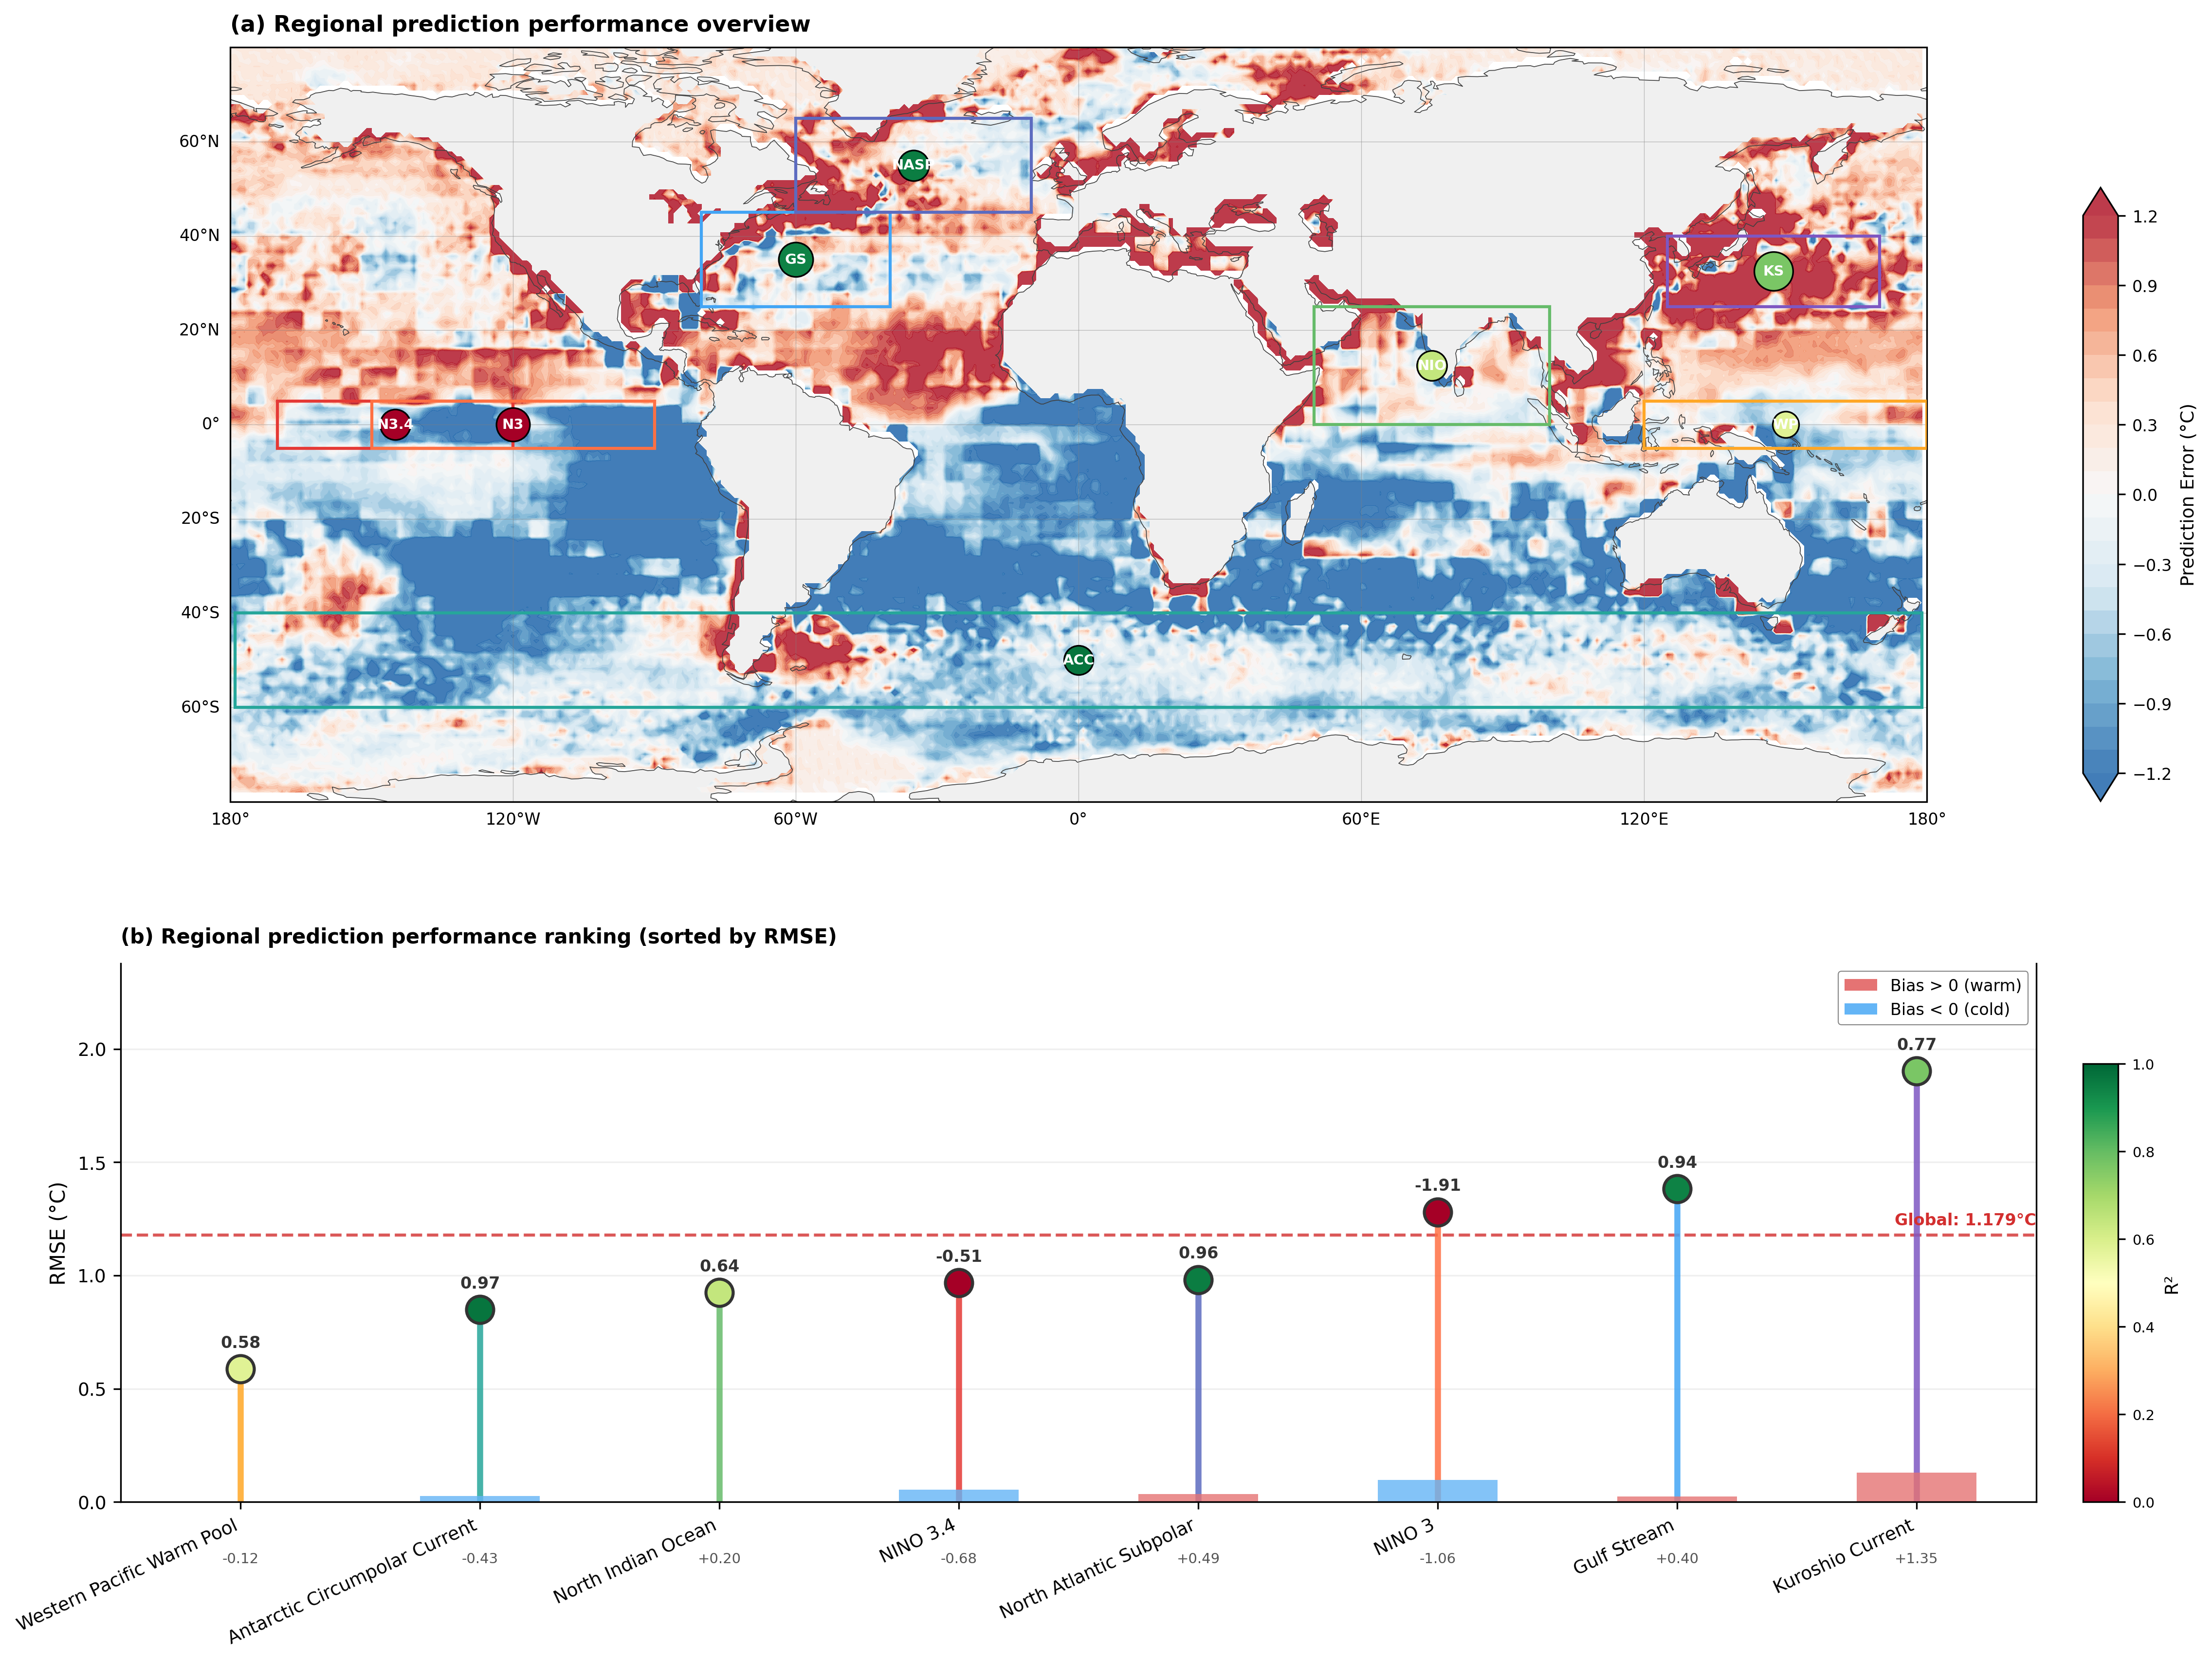


🔍 正在生成各区域详细分析图...
⚠️  区域 nino34 分析失败: 'transform' is not allowed as a keyword argument; axhline generates its own transform.
⚠️  区域 gulf_stream 分析失败: 'transform' is not allowed as a keyword argument; axhline generates its own transform.
⚠️  区域 kuroshio 分析失败: 'transform' is not allowed as a keyword argument; axhline generates its own transform.
⚠️  区域 acc 分析失败: 'transform' is not allowed as a keyword argument; axhline generates its own transform.
⚠️  区域 warm_pool 分析失败: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

📋 正在生成汇总表格...
✅ 汇总表格已保存: out/sst/regional/regional_analysis_summary.csv

📊 各海域预测性能汇总（按 RMSE 排序）:
----------------------------------------------------------------------------------------------------
     区域                           英文名 RMSE (°C) MAE (°C)      R² 系统偏差 (°C) 真实温度均值 (°C) 空间变异性 (°C)
赤道太平洋暖池     Western Pacific Warm Pool    0.5867   0.4559  0.5791   -0.1238       29.53      0.904
南大洋西风漂流 Antarctic Circumpolar Current    0.8

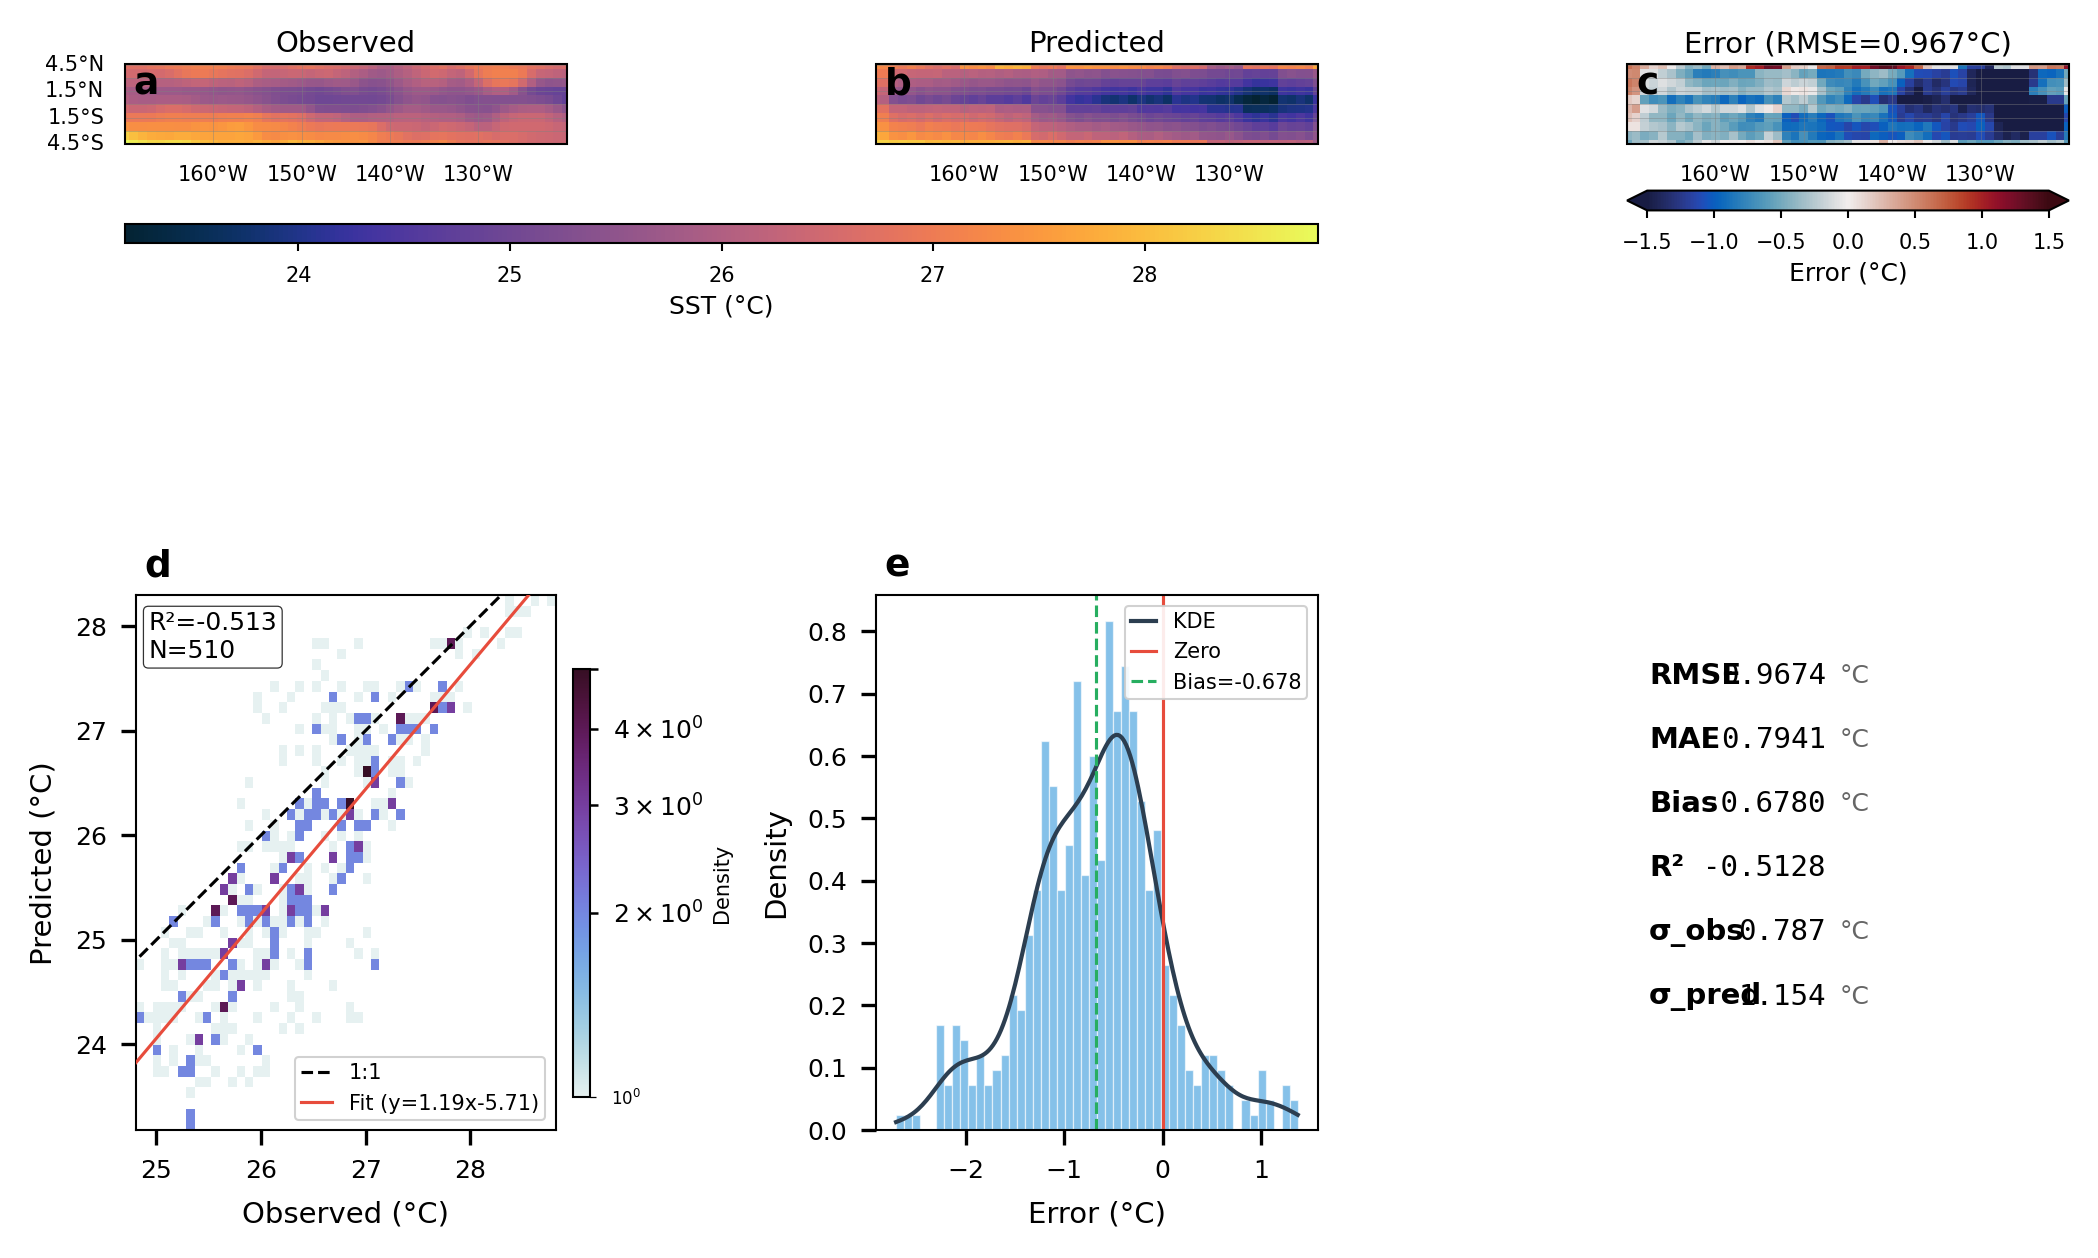

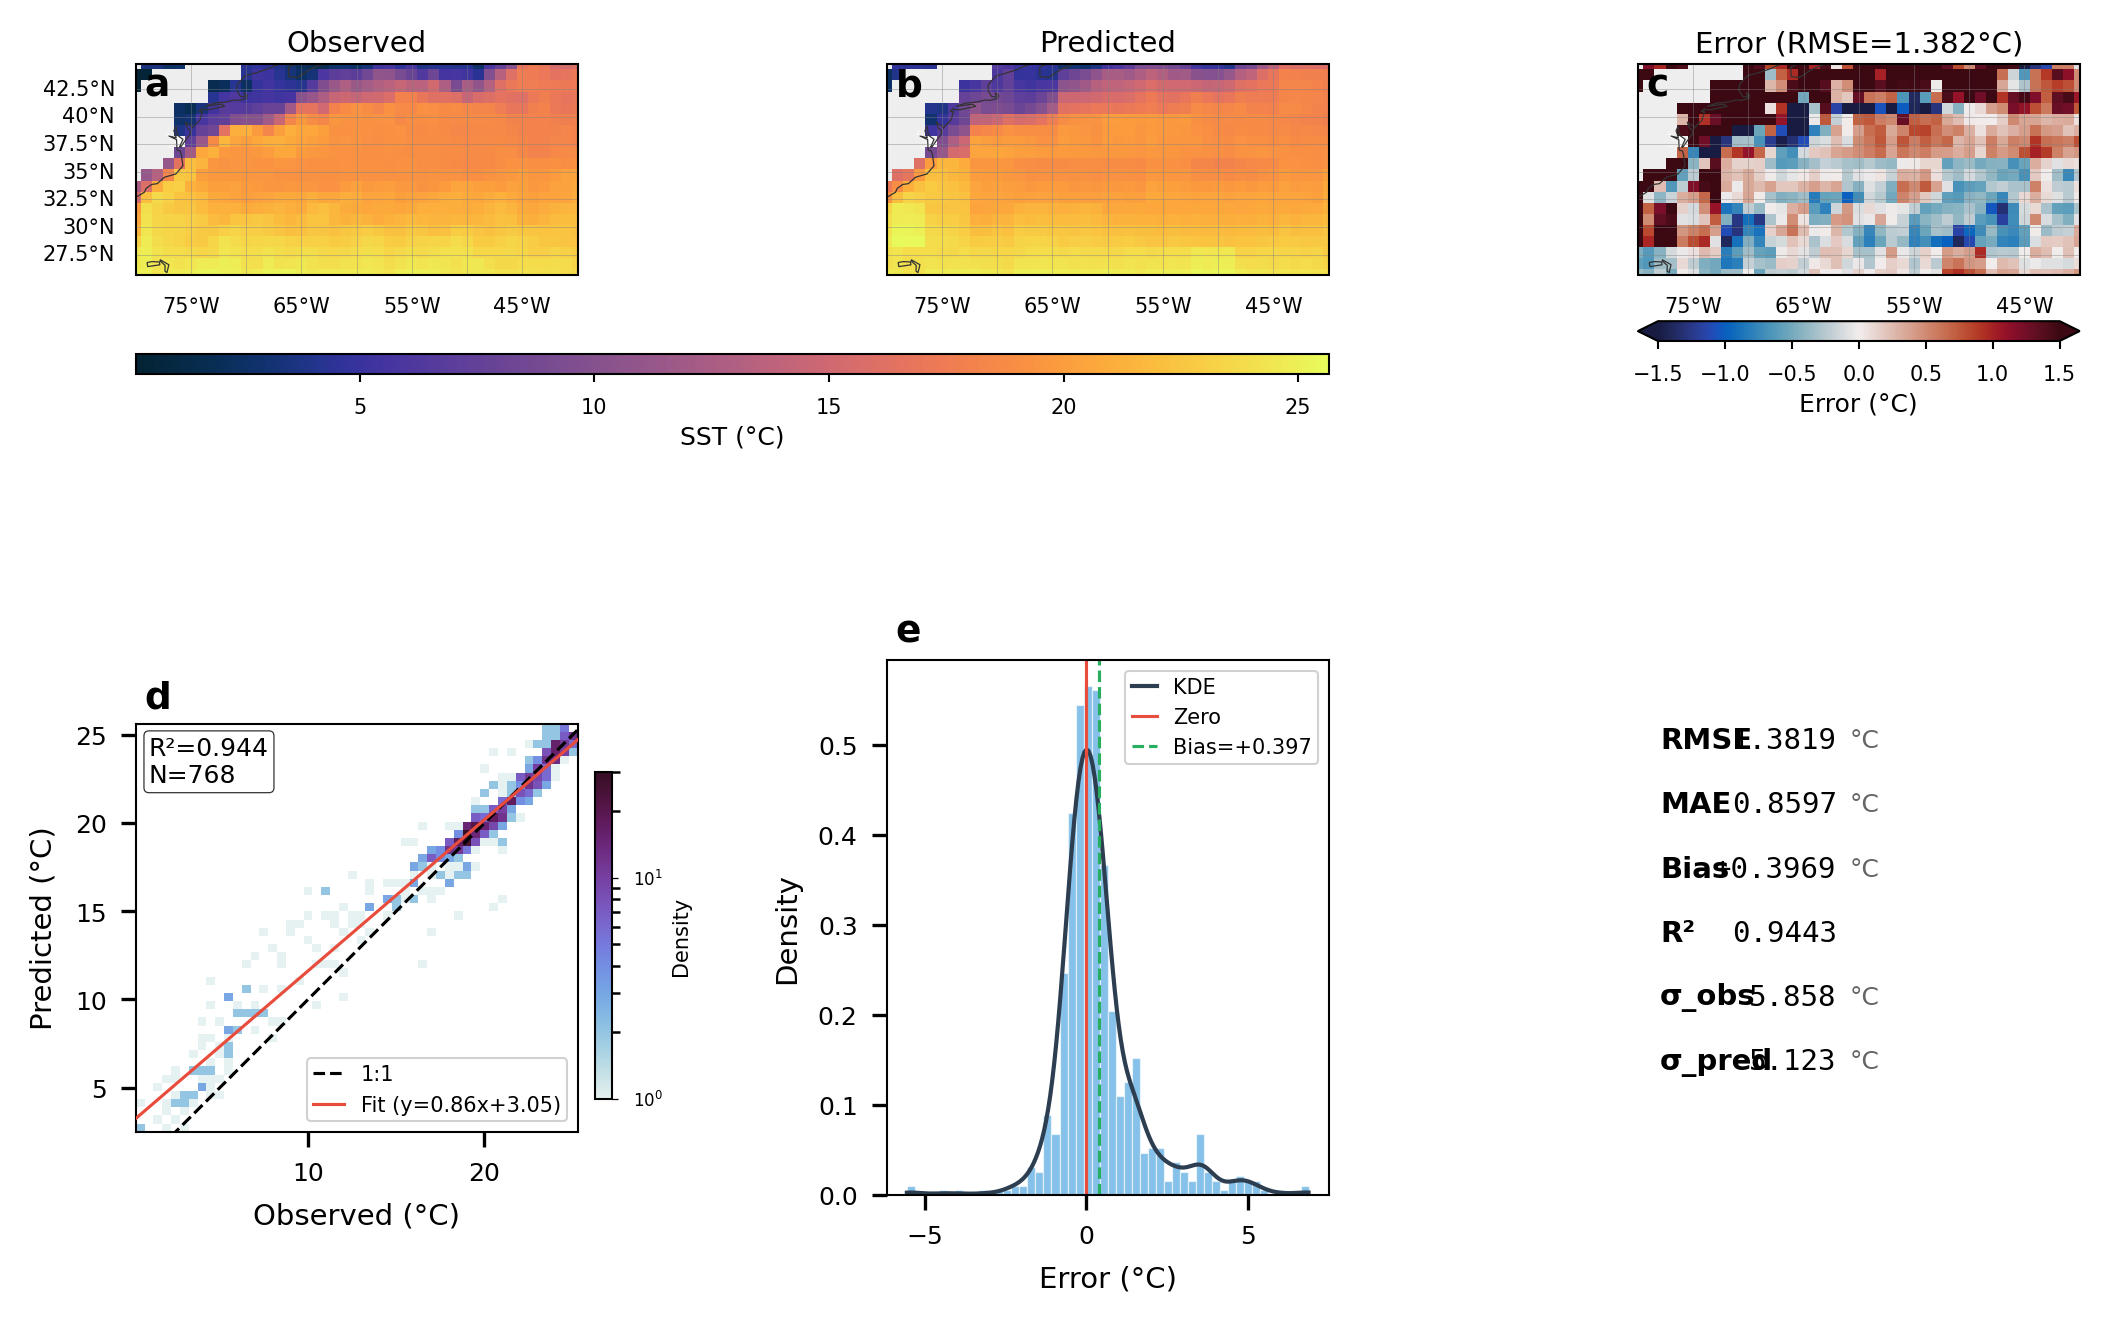

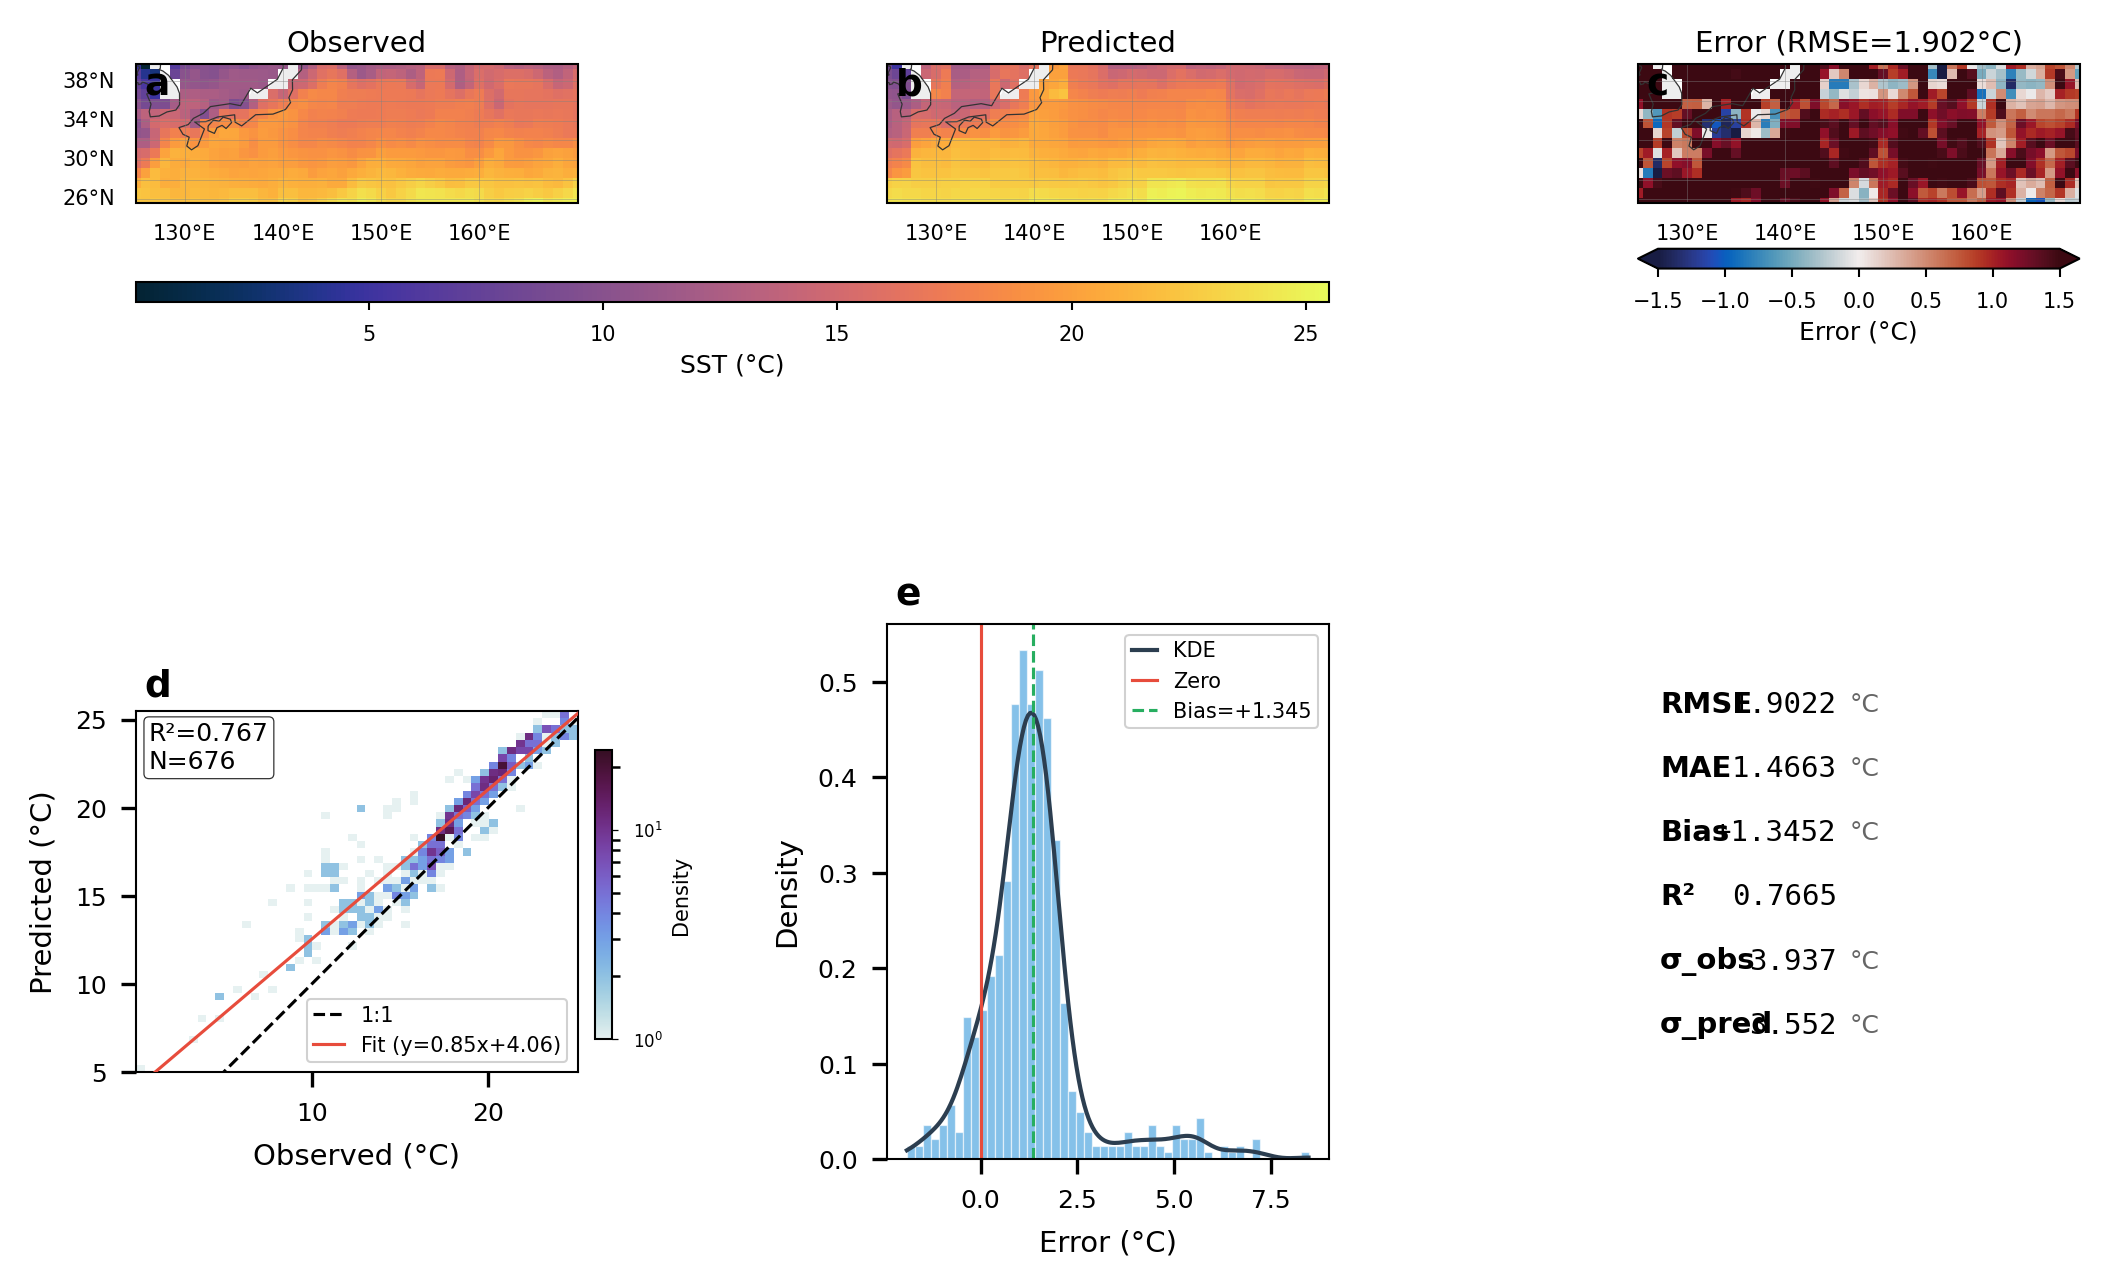

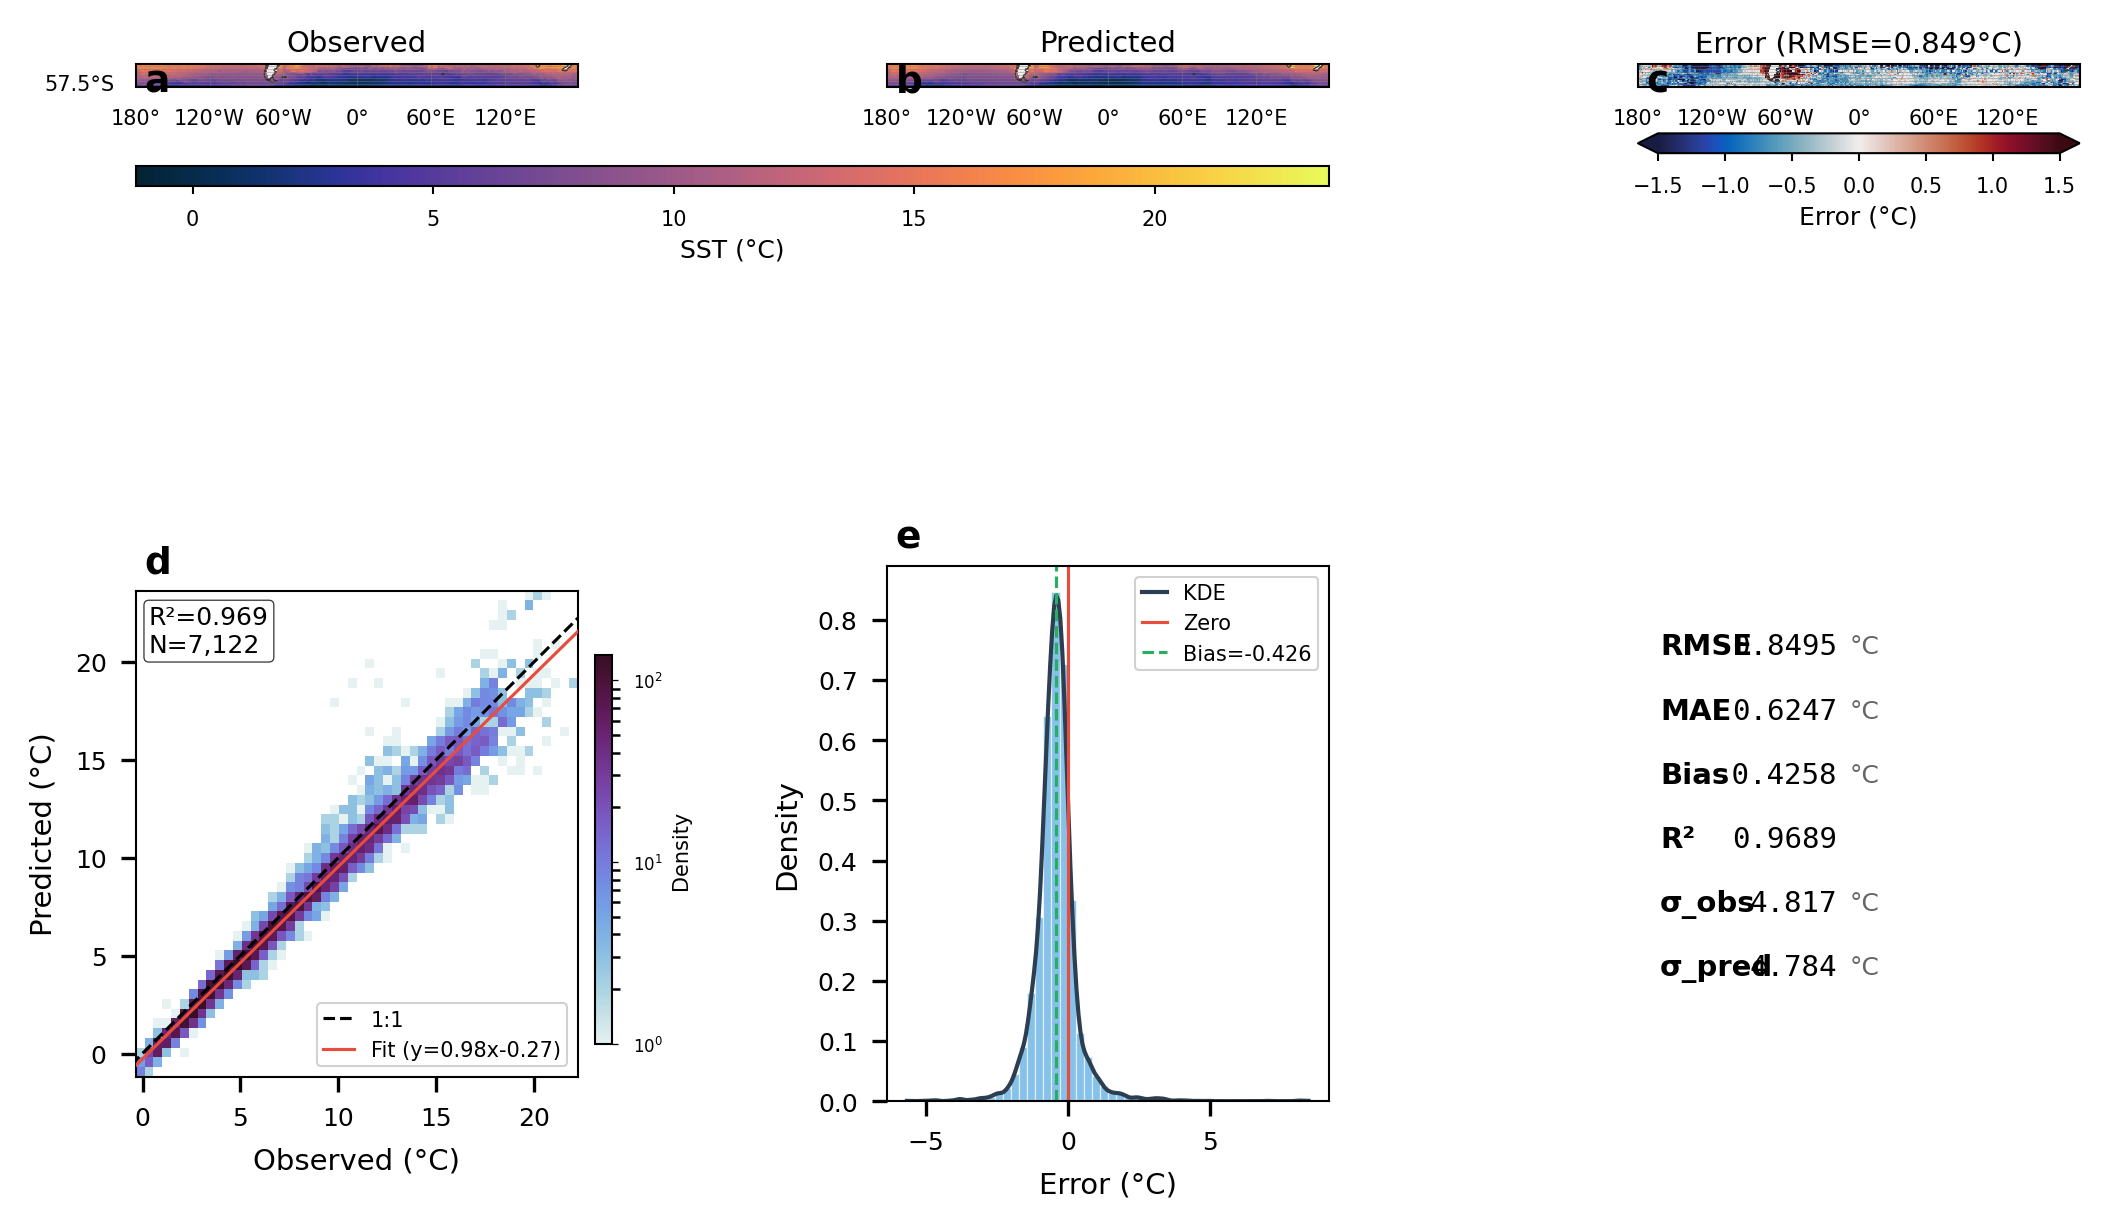

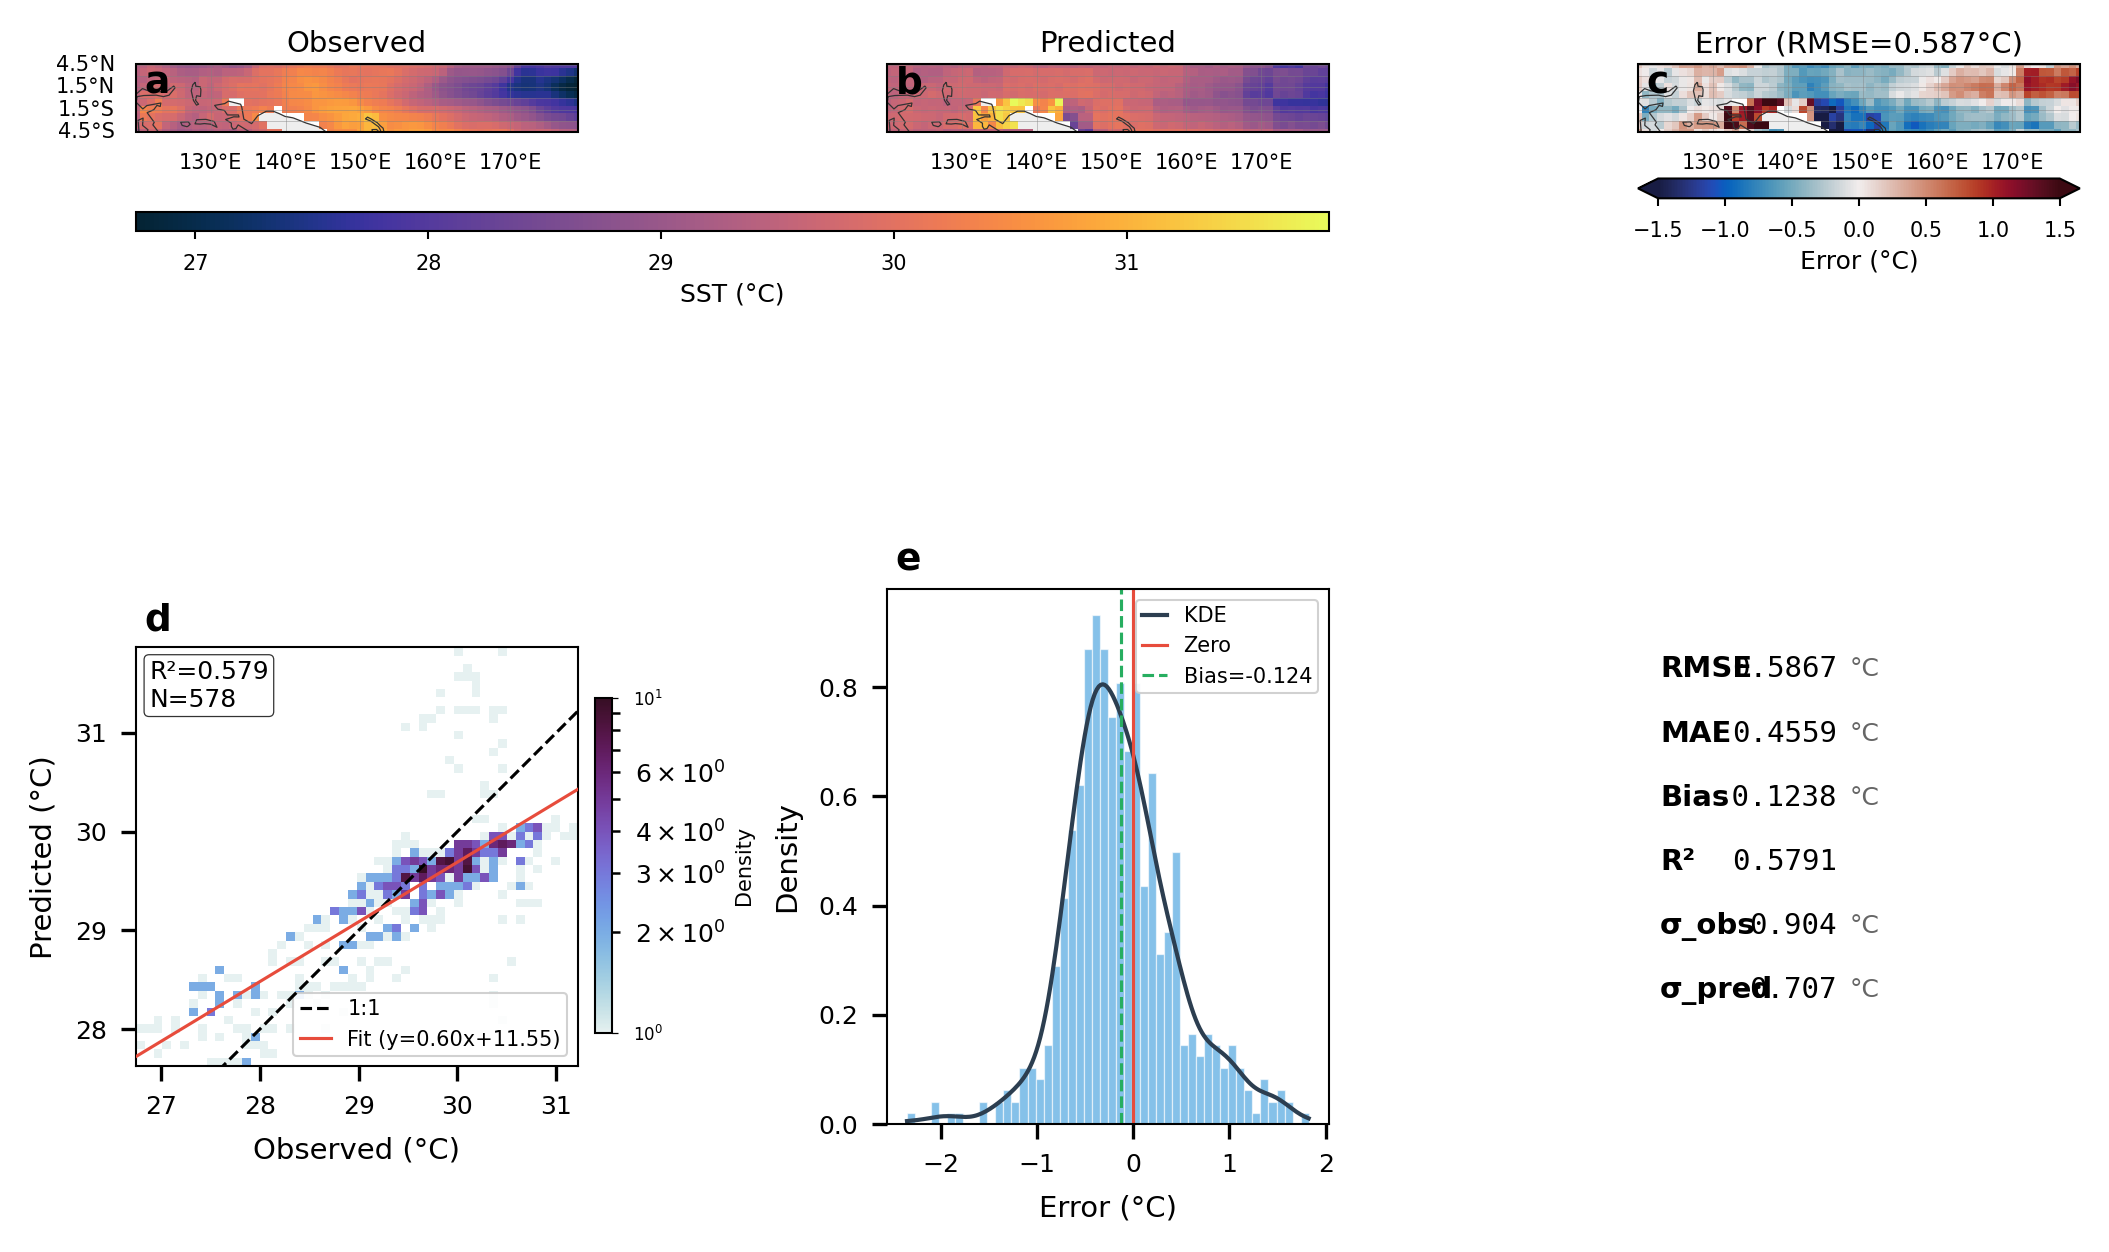

In [16]:
# %% 3. 区域性分析
# 说明：对关键海洋区域进行针对性分析，生成详细的区域统计报告和可视化图表
# 需要先有训练好的checkpoint

from src.analysis.regional import run_regional_analysis

print("=" * 70)
print("🌊 区域性分析阶段")
print("=" * 70)

# 如果还没有创建 eval_trainer，先创建
if 'eval_trainer' not in dir():
    eval_trainer = BasePrediction(
        wandb_run_id=pretrain_trainer.trainer_uid,  # 修改为你的 run_id
        area=area,
        model_class=RGTransformer,
        dataset_class=OISSTMonthlyDataset,
        dataset_params=dataset_params,
        model_params=rg_transformer_m_params,
    )

# 运行完整的区域分析
# 参数说明：
#   - test_offset: 测试时间点
#   - save_dir: 保存目录
#   - detail_regions: 需要详细分析的区域，可选：
#       'nino34'（厄尔尼诺监测区）, 'nino3'（东太平洋暖池）, 
#       'warm_pool'（赤道太平洋暖池）, 'gulf_stream'（墨西哥湾暖流）,
#       'kuroshio'（黑潮）, 'acc'（南大洋西风漂流）, 
#       'north_indian'（北印度洋）, 'north_atlantic_subpolar'（北大西洋副极地）
#   - show_plots: 是否显示图表

analyzer, stats, summary_df = run_regional_analysis(
    predictor=eval_trainer,
    area=area,
    resolution=resolution,
    test_offset=520,
    save_dir='out/sst/regional',
    detail_regions=['nino34', 'gulf_stream', 'kuroshio', 'acc', 'warm_pool'],
    show_plots=True
)

print("\n✅ 区域分析完成！")
